# Sentence Piece tokenizer trained on bengaliai-speech competation text data

for more inf about **Sentence Piece** algorithm and how it work plz refer to official repo can be found [here](https://github.com/google/sentencepiece) and read this [blog](https://colabdoge.medium.com/understanding-sentencepiece-under-standing-sentence-piece-ac8da59f6b08) to get full understanding of how it work 

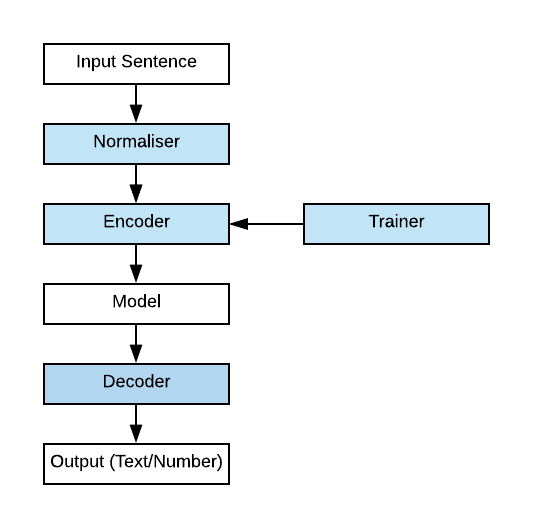

# 1- Install Sentence Piece from source

In [1]:
!sudo apt-get install cmake build-essential pkg-config libgoogle-perftools-dev -y

Reading package lists... Done
Building dependency tree       
Reading state information... Done
pkg-config is already the newest version (0.29.1-0ubuntu4).
build-essential is already the newest version (12.8ubuntu1.1).
cmake is already the newest version (3.16.3-1ubuntu1.20.04.1).
The following additional packages will be installed:
  libgoogle-perftools4 liblzma-dev libtcmalloc-minimal4 libunwind-dev
Suggested packages:
  liblzma-doc
The following NEW packages will be installed:
  libgoogle-perftools-dev libgoogle-perftools4 liblzma-dev
  libtcmalloc-minimal4 libunwind-dev
0 upgraded, 5 newly installed, 0 to remove and 6 not upgraded.
Need to get 1352 kB of archives.
After this operation, 10.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/main amd64 libtcmalloc-minimal4 amd64 2.7-1ubuntu2 [93.0 kB]
Get:2 http://archive.ubuntu.com/ubuntu focal/main amd64 libgoogle-perftools4 amd64 2.7-1ubuntu2 [195 kB]
Get:3 http://archive.ubuntu.com/ubuntu foca

In [2]:
import os

In [3]:
! git clone https://github.com/google/sentencepiece.git 
os.chdir('sentencepiece')
! mkdir build
os.chdir('build')
! cmake ..
! make -j $(nproc)
! sudo make install
! sudo ldconfig -v

Cloning into 'sentencepiece'...
remote: Enumerating objects: 4823, done.
remote: Counting objects: 100% (1446/1446), done.
remote: Compressing objects: 100% (323/323), done.
remote: Total 4823 (delta 1167), reused 1189 (delta 1082), pack-reused 3377
Receiving objects: 100% (4823/4823), 26.77 MiB | 22.27 MiB/s, done.
Resolving deltas: 100% (3316/3316), done.
cmake: /opt/conda/lib/libcurl.so.4: no version information available (required by cmake)
-- VERSION: 0.2.00
-- The C compiler identification is GNU 9.4.0
-- The CXX compiler identification is GNU 9.4.0
-- Check for working C compiler: /usr/bin/cc
-- Check for working C compiler: /usr/bin/cc -- works
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Detecting C compile features
-- Detecting C compile features - done
-- Check for working CXX compiler: /usr/bin/c++
-- Check for working CXX compiler: /usr/bin/c++ -- works
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Detecting 

In [4]:
os.chdir('/kaggle/working')
!ls

sentencepiece


# 2- Extract text type data from dataset and save it as txt file format

In [5]:
import pandas as pd

In [6]:
data = pd.read_csv('/kaggle/input/bengaliai-speech/train.csv')['sentence'].tolist()

In [7]:
with open('bn-speech.txt', 'w') as f:
    text = '\n'.join(data)
    f.write(text)

# 3- Train the tokenizer

## Usage: spm_train [options] files

   **--help** (show help)  type: bool default: false
   
   **--version** (show version)  type: bool default: false
   
   **--minloglevel** (Messages logged at a lower level than this don't actually get logged anywhere)  type: int default: 0
   
   **--input** (comma separated list of input sentences)  type: std::string default: ""
   
   **--input_format** (Input format. Supported format is `text` or `tsv`.)  type: std::string default: ""
   
   **--model_prefix** (output model prefix)  type: std::string default: ""
   
   **--model_type** (model algorithm: unigram, bpe, word or char)  type: std::string default: "unigram"
   
   **--vocab_size** (vocabulary size)  type: int32 default: 8000
   
   **--accept_language** (comma-separated list of languages this model can accept)  type: std::string default: ""
   
   **--self_test_sample_size** (the size of self test samples)  type: int32 default: 0
   
   **--character_coverage** (character coverage to determine the minimum symbols)  type: double default: 0.9995
   
   **--input_sentence_size** (maximum size of sentences the trainer loads)  type: std::uint64_t default: 0
   
   **--shuffle_input_sentence** (Randomly sample input sentences in advance. Valid when --input_sentence_size > 0)  type: bool default: true
   
   **--seed_sentencepiece_size** (the size of seed sentencepieces)  type: int32 default: 1000000
   
   **--shrinking_factor** (Keeps top shrinking_factor pieces with respect to the loss)  type: double default: 0.75
   
   **--num_threads** (number of threads for training)  type: int32 default: 16
   
   **--num_sub_iterations** (number of EM sub-iterations)  type: int32 default: 2
   
   **--max_sentencepiece_length** (maximum length of sentence piece)  type: int32 default: 16
   
   **--max_sentence_length** (maximum length of sentence in byte)  type: int32 default: 4192
   
   **--split_by_unicode_script** (use Unicode script to split sentence pieces)  type: bool default: true
   
   **--split_by_number** (split tokens by numbers (0-9))  type: bool default: true
   
   **--split_by_whitespace** (use a white space to split sentence pieces)  type: bool default: true
   
   **--split_digits** (split all digits (0-9) into separate pieces)  type: bool default: false
   
   **--pretokenization_delimiter** (specifies the delimiter of pre-tokenization)  type: std::string default: ""
   
   **--treat_whitespace_as_suffix** (treat whitespace marker as suffix instead of prefix.)  type: bool default: false
   
   **--allow_whitespace_only_pieces** (allow pieces that only contain (consecutive) whitespace tokens)  type: bool default: false
   
   **--control_symbols** (comma separated list of control symbols)  type: std::string default: ""
   
   **--control_symbols_file** (load control_symbols from file.)  type: std::string default: ""
   
   **--user_defined_symbols** (comma separated list of user defined symbols)  type: std::string default: ""
   
   **--user_defined_symbols_file** (load user_defined_symbols from file.)  type: std::string default: ""
   
   **--required_chars** (UTF8 characters in this flag are always used in the character set regardless of --character_coverage)  type: std::string default: ""
   
   **--required_chars_file** (load required_chars from file.)  type: std::string default: ""
   
   **--byte_fallback** (decompose unknown pieces into UTF-8 byte pieces)  type: bool default: false
   
   **--vocabulary_output_piece_score** (Define score in vocab file)  type: bool default: true
   
   **--normalization_rule_name** (Normalization rule name. Choose from nfkc or identity)  type: std::string default: "nmt_nfkc"
   
   **--normalization_rule_tsv** (Normalization rule TSV file. )  type: std::string default: ""
   
   **--denormalization_rule_tsv** (Denormalization rule TSV file.)  type: std::string default: ""
   
   **--add_dummy_prefix** (Add dummy whitespace at the beginning of text)  type: bool default: true
   
   **--remove_extra_whitespaces** (Removes leading, trailing, and duplicate internal whitespace)  type: bool default: true
   
   **--hard_vocab_limit** (If set to false, --vocab_size is considered as a soft limit.)  type: bool default: true
   
   **--use_all_vocab** (If set to true, use all tokens as vocab. Valid for word/char models.)  type: bool default: false
   
   **--unk_id** (Override UNK (\<unk>) id.)  type: int32 default: 0
    
   **--bos_id** (Override BOS (\<s>) id. Set -1 to disable BOS.)  type: int32 default: 1
    
   **--eos_id** (Override EOS (\</s>) id. Set -1 to disable EOS.)  type: int32 default: 2
    
   **--pad_id** (Override PAD (\<pad>) id. Set -1 to disable PAD.)  type: int32 default: -1
    
   **--unk_piece** (Override UNK (\<unk>) piece.)  type: std::string default: "\<unk>"
    
   **--bos_piece** (Override BOS (\<s>) piece.)  type: std::string default: "\<s>"
    
   **--eos_piece** (Override EOS (\</s>) piece.)  type: std::string default: "\</s>"
    
   **--pad_piece** (Override PAD (\<pad>) piece.)  type: std::string default: "\<pad>"
    
   **--unk_surface** (Dummy surface string for \<unk>. In decoding \<unk> is decoded to `unk_surface`.)  type: std::string default: " ⁇ "
    
   **--train_extremely_large_corpus** (Increase bit depth for unigram tokenization.)  type: bool default: false
    
   **--random_seed** (Seed value for random generator.)  type: uint32 default: 4294967295
    
   **--enable_differential_privacy** (Whether to add DP while training. Currently supported only by UNIGRAM model.)  type: bool default: false
    
   **--differential_privacy_noise_level** (Amount of noise to add for DP)  type: float default: 0
    
   **--differential_privacy_clipping_threshold** (Threshold for clipping the counts for DP)  type: std::uint64_t default: 0


In [8]:
!spm_train --input=bn-speech.txt --model_prefix=spm --vocab_size=8000 --character_coverage=0.9999 num_threads=4 --pad_id=0 --unk_id=3 --bos_id=1 --eos_id=2

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: bn-speech.txt
  input_format: 
  model_prefix: spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9999
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_noise_level: 0
  d

In [9]:
!ls

bn-speech.txt  sentencepiece  spm.model  spm.vocab


In [10]:
!spm_export_vocab --model=spm.model --output=spm.spm

In [13]:
!rm bn-speech.txt
!rm -r sentencepiece/

In [14]:
!ls

spm.model  spm.spm  spm.vocab
